In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

In [34]:
df = pd.read_csv(r"C:\Users\Thanuja C\OneDrive\Desktop\insurance_dataset.csv")
df.head()

,age,gender,annual_income,policy_type,premium_amount,incident_type,incident_hour,num_witnesses,police_report,previous_claims,vehicle_age,region_risk,claim_amount,claim_frequency,claim_to_premium_ratio,fraud_label
0,56,Male,1986357,Basic,41476,Fire,13,4,0,8,6,0.151718,219284.66710,0.205128,5.287025,1
1,69,Female,1602964,Gold,31283,Collision,13,5,0,7,10,0.545367,132194.81060,0.134615,4.225772,0
2,46,Female,789872,Gold,6769,Other,17,0,1,8,9,0.383996,44660.96940,0.275862,6.597868,0
3,32,Male,1661742,Basic,47278,Fire,1,1,1,4,5,0.104417,89985.91498,0.266667,1.903336,0
4,60,Male,1919109,Gold,51994,Collision,0,3,0,3,0,0.264965,240843.74280,0.069767,4.632145,0


In [35]:
# Check missing values
print(df.isnull().sum())

# Remove duplicates (if any)
df = df.drop_duplicates()

# Basic info
df.info()

age                       0
gender                    0
annual_income             0
policy_type               0
premium_amount            0
incident_type             0
incident_hour             0
num_witnesses             0
police_report             0
previous_claims           0
vehicle_age               0
region_risk               0
claim_amount              0
claim_frequency           0
claim_to_premium_ratio    0
fraud_label               0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5000 non-null   int64  
 1   gender                  5000 non-null   str    
 2   annual_income           5000 non-null   int64  
 3   policy_type             5000 non-null   str    
 4   premium_amount          5000 non-null   int64  
 5   incident_type           5000 non-null   str    
 6   incident_hour 

In [36]:
le = LabelEncoder()

for col in ["gender", "policy_type", "incident_type"]:
    df[col] = le.fit_transform(df[col])

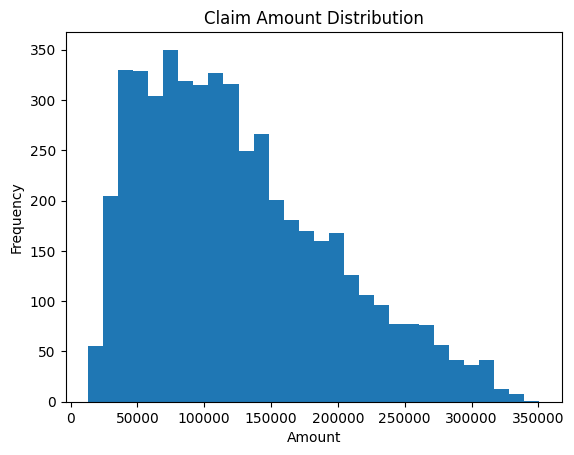

In [37]:
#Claim Amount Distribution
plt.figure()
plt.hist(df["claim_amount"], bins=30)
plt.title("Claim Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

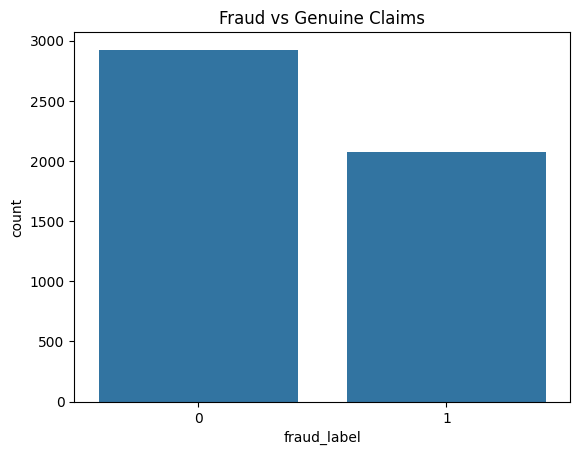

In [38]:
#Fraud Distribution
plt.figure()
sns.countplot(x="fraud_label", data=df)
plt.title("Fraud vs Genuine Claims")
plt.show()

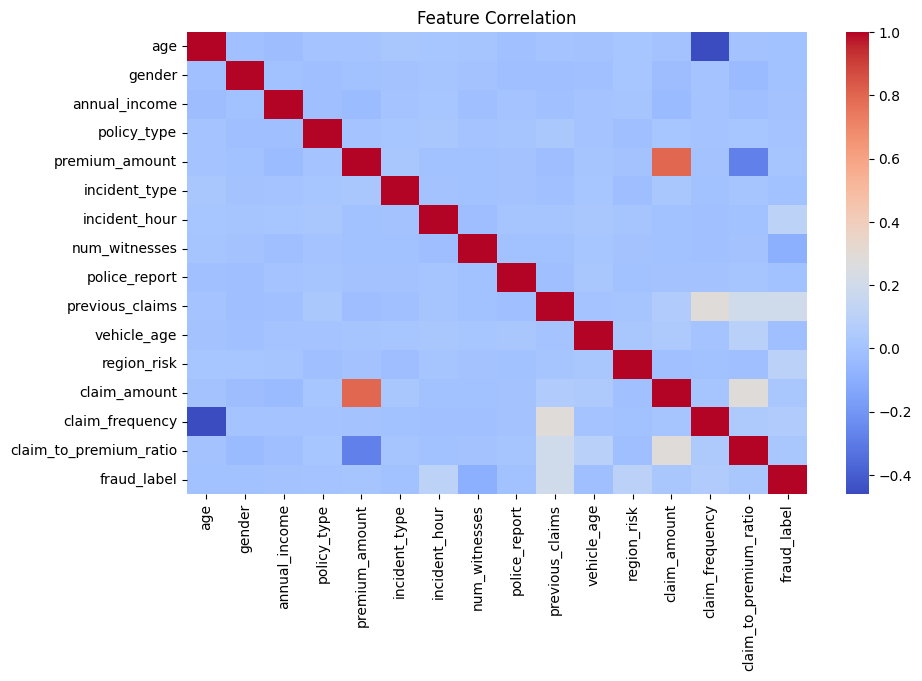

In [39]:
#Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

🚀 MODEL 1: CLAIM AMOUNT PREDICTION

In [40]:
X_reg = df.drop(["claim_amount", "fraud_label"], axis=1)
y_reg = df["claim_amount"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [41]:
reg_model = RandomForestRegressor()
reg_model.fit(X_train_r, y_train_r)

pred_claim = reg_model.predict(X_test_r)

In [42]:
mae = mean_absolute_error(y_test_r, pred_claim)
print("MAE (Claim Prediction):", mae)

MAE (Claim Prediction): 1212.7913206587998


🚨 MODEL 2: FRAUD DETECTION

In [43]:
X_clf = df.drop(["fraud_label"], axis=1)
y_clf = df["fraud_label"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

In [44]:
clf_model = RandomForestClassifier()
clf_model.fit(X_train_c, y_train_c)

pred_fraud = clf_model.predict(X_test_c)

In [45]:
print("Accuracy:", accuracy_score(y_test_c, pred_fraud))
print(classification_report(y_test_c, pred_fraud))

Accuracy: 0.641
              precision    recall  f1-score   support

           0       0.66      0.78      0.72       587
           1       0.59      0.44      0.50       413

    accuracy                           0.64      1000
   macro avg       0.63      0.61      0.61      1000
weighted avg       0.63      0.64      0.63      1000



🔥 MODEL 3: RISK SCORING ENGINE (YOUR USP)

In [46]:
df["fraud_probability"] = clf_model.predict_proba(X_clf)[:, 1]

In [47]:
df["risk_score"] = (
    0.4 * df["fraud_probability"] +
    0.3 * df["claim_to_premium_ratio"] +
    0.2 * df["claim_frequency"] +
    0.1 * (df["previous_claims"] / 10)
)

In [48]:
def risk_category(score):
    if score < 0.3:
        return "Low"
    elif score < 0.7:
        return "Medium"
    else:
        return "High"

df["risk_category"] = df["risk_score"].apply(risk_category)

df[["risk_score", "risk_category"]].head()

,risk_score,risk_category
0,2.019133,High
1,1.432655,High
2,2.214533,High
3,0.688334,Medium
4,1.485597,High


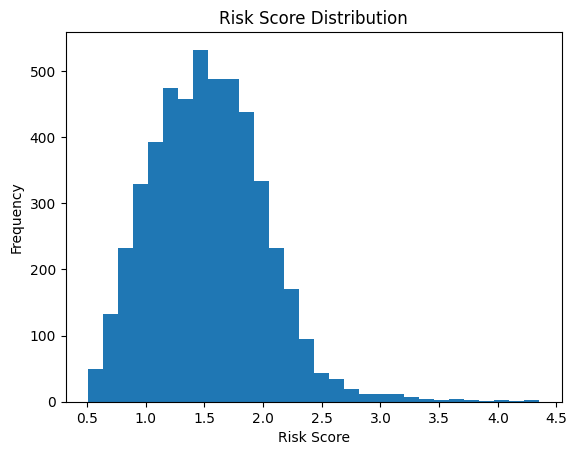

In [49]:
plt.figure()
plt.hist(df["risk_score"], bins=30)
plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.show()

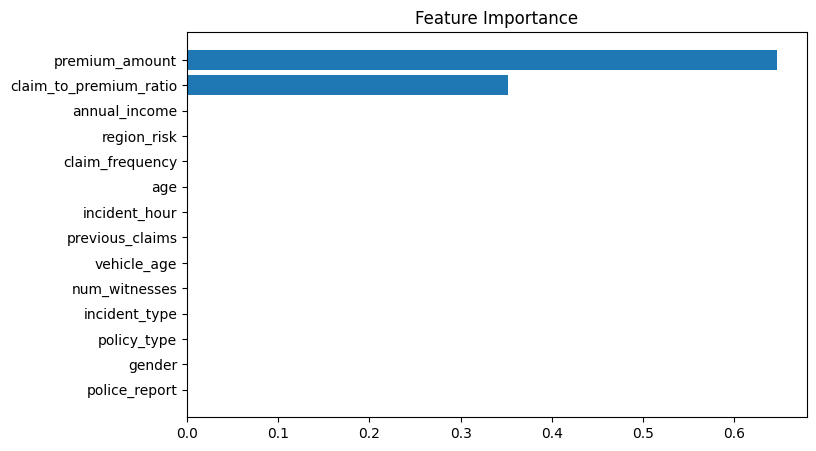

In [50]:
importance = reg_model.feature_importances_

feat_df = pd.DataFrame({
    "Feature": X_reg.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
plt.barh(feat_df["Feature"], feat_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

In [51]:
print("Project Summary:")
print("✔ Claim Amount Prediction using Regression")
print("✔ Fraud Detection using Classification")
print("✔ Custom Risk Scoring Engine combining multiple factors")

Project Summary:
✔ Claim Amount Prediction using Regression
✔ Fraud Detection using Classification
✔ Custom Risk Scoring Engine combining multiple factors


In [1]:
reg_model = pickle.load(open(r"C:\coding\ML activity\models\reg_model.pkl", "rb"))
clf_model = pickle.load(open(r"C:\coding\ML activity\models\clf_model.pkl", "rb"))

NameError: name 'pickle' is not defined

In [2]:
import pickle

reg_model = pickle.load(open(r"C:\coding\ML activity\models\reg_model.pkl", "rb"))
clf_model = pickle.load(open(r"C:\coding\ML activity\models\clf_model.pkl", "rb"))

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\coding\\ML activity\\models\\reg_model.pkl'